# Leading Edge Reconstruction from Sparse Samples
**ZCU106 / PYNQ** — weryfikacja koprocesora AXI-Lite  
Metody: Linear, Exponential, Logarithmic | Format: Q16.16 | 3 próbki PMT

## 1. Załadowanie overlay

In [35]:
from pynq import Overlay
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

ol = Overlay('zcu106_leading_edge_axi_lite.xsa')
print(ol.ip_dict.keys())

dict_keys(['myip_leading_edge_ax_0', 'zynq_ultra_ps_e_0'])


In [19]:
from pynq import Overlay
ol = Overlay('zcu106_leading_edge_axi_lite.xsa', download=True)
ip = ol.myip_leading_edge_ax_0

In [20]:
import zipfile, os

xsa = 'zcu106_leading_edge_axi_lite.xsa'
hwh_dst = xsa.replace('.xsa', '.hwh')

if not os.path.exists(hwh_dst):
    with zipfile.ZipFile(xsa, 'r') as z:
        hwh_inside = [f for f in z.namelist() if f.endswith('.hwh')][0]
        with z.open(hwh_inside) as src, open(hwh_dst, 'wb') as dst:
            dst.write(src.read())

from pynq import Overlay
ol = Overlay(xsa)
ip = ol.myip_leading_edge_ax_0

# Weryfikacja - sprawdz adres bazowy IP
print(f'IP base address: 0x{ip.mmio.base_addr:08X}')
print('Overlay zaladowany OK')

IP base address: 0xA0000000
Overlay zaladowany OK


## 2. Mapa rejestrów i funkcje pomocnicze

| Offset | Nazwa    | Opis                          |
|--------|----------|-------------------------------|
| 0x00   | CTRL     | [0]=start, [2:1]=mode_sel     |
| 0x04   | STATUS   | [0]=done, [1]=valid, [2]=ovf  |
| 0x08   | T1       | Q16.16 [ns]                   |
| 0x0C   | A1       | Q16.16                        |
| 0x10   | T2       | Q16.16 [ns]                   |
| 0x14   | A2       | Q16.16                        |
| 0x18   | T3       | Q16.16 [ns]                   |
| 0x1C   | A3       | Q16.16                        |
| 0x20   | THRESH   | Q16.16                        |
| 0x24   | T0_EST   | Q16.16 wynik (R/O)            |
| 0x28   | AMAX_EST | Q16.16 wynik (R/O)            |
| 0x2C   | EVENT_ID | uint32 (R/O)                  |

In [21]:
# Offsety rejestrow
REG_CTRL     = 0x00
REG_STATUS   = 0x04
REG_T1       = 0x08
REG_A1       = 0x0C
REG_T2       = 0x10
REG_A2       = 0x14
REG_T3       = 0x18
REG_A3       = 0x1C
REG_THRESH   = 0x20
REG_T0_EST   = 0x24
REG_AMAX_EST = 0x28
REG_EVENT_ID = 0x2C

MODE_LIN = 0  # 00
MODE_EXP = 1  # 01
MODE_LOG = 2  # 10

def to_q16(v):
    """float -> Q16.16 uint32"""
    return int(round(v * 65536.0)) & 0xFFFFFFFF

def from_q16(v):
    """Q16.16 uint32 -> float (signed)"""
    v = int(v) & 0xFFFFFFFF
    if v & 0x80000000:
        v -= 0x100000000
    return v / 65536.0

def ip_write(offset, value):
    ip.write(offset, int(value) & 0xFFFFFFFF)

def ip_read(offset):
    return ip.read(offset)

print('Funkcje pomocnicze zaladowane.')

Funkcje pomocnicze zaladowane.


## 3. Funkcja obliczeniowa koprocesora

In [22]:
def fpga_compute(t1, a1, t2, a2, t3, a3, threshold, mode, timeout=10000):
    """
    Uruchamia koprocesor FPGA i zwraca (t0_est, amax_est, overflow).
    mode: 0=LIN, 1=EXP, 2=LOG
    """
    # Wpisz dane wejsciowe
    ip_write(REG_T1,     to_q16(t1))
    ip_write(REG_A1,     to_q16(a1))
    ip_write(REG_T2,     to_q16(t2))
    ip_write(REG_A2,     to_q16(a2))
    ip_write(REG_T3,     to_q16(t3))
    ip_write(REG_A3,     to_q16(a3))
    ip_write(REG_THRESH, to_q16(threshold))

    # Start: mode_sel w bitach [2:1], start w bicie [0]
    ip_write(REG_CTRL, (mode << 1) | 1)

    # Czekaj na done
    for _ in range(timeout):
        status = ip_read(REG_STATUS)
        if status & 0x1:
            break
    else:
        return None, None, None  # timeout

    t0_est   = from_q16(ip_read(REG_T0_EST))
    amax_est = from_q16(ip_read(REG_AMAX_EST))
    overflow = bool((ip_read(REG_STATUS) >> 2) & 1)

    # Reset CTRL
    ip_write(REG_CTRL, 0)

    return t0_est, amax_est, overflow

print('fpga_compute() gotowa.')

fpga_compute() gotowa.


## 4. Golden model Python (referencja)

In [23]:
def python_linear(t1, a1, t2, a2, threshold):
    """t0 przez interpolacje liniowa miedzy (t1,a1) i (t2,a2)"""
    if (a2 - a1) == 0:
        return None
    t0 = t1 + (threshold - a1) * (t2 - t1) / (a2 - a1)
    return t0

def python_exponential(t1, a1, t2, a2, threshold):
    """t0 przez model eksponencjalny: A*exp(b*t)"""
    if a1 <= 0 or a2 <= 0 or a1 == a2:
        return None
    b  = (np.log(a2) - np.log(a1)) / (t2 - t1)
    lnA = np.log(a1) - b * t1
    if b == 0:
        return None
    t0 = (np.log(threshold) - lnA) / b
    return t0

def python_logarithmic(t1, a1, t2, a2, t3, a3, threshold):
    """t0 przez interpolacje logarytmiczna (3 punkty)"""
    if a1 <= 0 or a2 <= 0 or a3 <= 0:
        return None
    # Interpolacja kwadratowa w dziedzinie log
    l1, l2, l3 = np.log(a1), np.log(a2), np.log(a3)
    lt = np.log(threshold)
    # Interpolacja liniowa log(a) vs t miedzy t1,t2
    if (l2 - l1) == 0:
        return None
    t0 = t1 + (lt - l1) * (t2 - t1) / (l2 - l1)
    return t0

print('Golden model Python zaladowany.')

Golden model Python zaladowany.


## 5. Wczytanie danych CSV i obliczenia

In [24]:
df = pd.read_csv('example_samples.csv')
print(f'Wczytano {len(df)} zdarzen.')
df.head(3)

Wczytano 20 zdarzen.


,event_id,t1,A1,t2,A2,t3,A3,true_t0,true_amax,sigma_ns,tau_ns,threshold,charge,true_t_leading,true_t_trailing,true_tot
0,0,12.639493,0.242324,17.121957,1.106515,18.823771,1.397267,20.266829,1.499501,4.0,8.0,0.3,1.499501,13.091081,34.139669,21.048587
1,1,14.808737,0.318532,17.186481,0.680438,19.243297,0.977680,21.035520,1.070234,4.0,8.0,0.3,1.070234,14.655928,32.210319,17.554391
2,2,14.949275,1.051854,18.598672,3.691896,20.420526,5.054359,22.392033,5.722857,4.0,8.0,0.3,5.722857,12.678634,46.979561,34.300927


In [25]:
THRESHOLD = 0.3
MODE_NAMES = ['LIN', 'EXP', 'LOG']
MODES = [MODE_LIN, MODE_EXP, MODE_LOG]

results = []

for _, row in df.iterrows():
    ev   = int(row['event_id'])
    t1, a1 = row['t1'], row['A1']
    t2, a2 = row['t2'], row['A2']
    t3, a3 = row['t3'], row['A3']
    true_t0 = row['true_t_leading']

    # Python golden model
    py_lin = python_linear(t1, a1, t2, a2, THRESHOLD)
    py_exp = python_exponential(t1, a1, t2, a2, THRESHOLD)
    py_log = python_logarithmic(t1, a1, t2, a2, t3, a3, THRESHOLD)

    # FPGA
    for mode_idx, mode_name in zip(MODES, MODE_NAMES):
        t_start = time.time()
        fpga_t0, fpga_amax, ovf = fpga_compute(
            t1, a1, t2, a2, t3, a3, THRESHOLD, mode_idx
        )
        t_elapsed = time.time() - t_start

        py_t0 = {'LIN': py_lin, 'EXP': py_exp, 'LOG': py_log}[mode_name]

        err_vs_python = abs(fpga_t0 - py_t0)   if (fpga_t0 is not None and py_t0 is not None) else None
        err_vs_true   = abs(fpga_t0 - true_t0) if fpga_t0 is not None else None

        results.append({
            'event_id'      : ev,
            'mode'          : mode_name,
            'fpga_t0'       : fpga_t0,
            'python_t0'     : py_t0,
            'true_t0'       : true_t0,
            'err_vs_python' : err_vs_python,
            'err_vs_true'   : err_vs_true,
            'overflow'      : ovf,
            'time_s'        : t_elapsed,
        })

res = pd.DataFrame(results)
print(f'Obliczono {len(res)} wynikow ({len(df)} zdarzen x 3 metody).')

Obliczono 60 wynikow (20 zdarzen x 3 metody).


## 6. Wyniki — tabela

In [33]:
ip.write(REG_T1, 0x12345678)
print(f'T1 readback: 0x{ip.read(REG_T1):08X}')
ip.write(REG_T2, 0xDEADBEEF)
print(f'T2 readback: 0x{ip.read(REG_T2):08X}')

T1 readback: 0x12345678
T2 readback: 0xDEADBEEF


In [34]:
# Reset hard - zapisz 0 do wszystkich rejestrow
for offset in [0x00,0x04,0x08,0x0C,0x10,0x14,0x18,0x1C,0x20]:
    ip.write(offset, 0)

import time
time.sleep(0.01)

# Wpisz dane
ip.write(0x08, to_q16(13.44))
ip.write(0x0C, to_q16(1.25))
ip.write(0x10, to_q16(15.90))
ip.write(0x14, to_q16(3.65))
ip.write(0x18, to_q16(18.01))
ip.write(0x1C, to_q16(5.07))
ip.write(0x20, to_q16(0.3))

# Sprawdz czy dane sa w rejestrach
print(f'T1=0x{ip.read(0x08):08X} ({from_q16(ip.read(0x08)):.3f})')
print(f'A1=0x{ip.read(0x0C):08X} ({from_q16(ip.read(0x0C)):.3f})')

# Start mode=0 (LIN)
ip.write(0x00, 0x1)

# Czekaj dluzej - 1 sekunda
time.sleep(1.0)
print(f'STATUS po 1s: 0x{ip.read(0x04):08X}')
print(f'T0_EST po 1s: 0x{ip.read(0x24):08X} = {from_q16(ip.read(0x24)):.4f} ns')

T1=0x000D70A4 (13.440)
A1=0x00014000 (1.250)
STATUS po 1s: 0x00000000
T0_EST po 1s: 0x00000000 = 0.0000 ns


In [32]:
# Diagnostyka - uruchom w osobnej komorce
row = df.iloc[0]

# Wpisz dane
ip.write(REG_T1,     to_q16(row['t1']))
ip.write(REG_A1,     to_q16(row['A1']))
ip.write(REG_T2,     to_q16(row['t2']))
ip.write(REG_A2,     to_q16(row['A2']))
ip.write(REG_T3,     to_q16(row['t3']))
ip.write(REG_A3,     to_q16(row['A3']))
ip.write(REG_THRESH, to_q16(0.3))

# Odczyt przed startem
print(f'STATUS przed startem: 0x{ip.read(REG_STATUS):08X}')
print(f'CTRL   przed startem: 0x{ip.read(REG_CTRL):08X}')

# Start
ip.write(REG_CTRL, (MODE_LIN << 1) | 1)
print(f'CTRL   po write:      0x{ip.read(REG_CTRL):08X}')

# Czekaj i sprawdzaj
import time
for i in range(20):
    time.sleep(0.001)
    s = ip.read(REG_STATUS)
    c = ip.read(REG_CTRL)
    print(f'  iter {i:2d}: STATUS=0x{s:08X} CTRL=0x{c:08X}')
    if s & 1:
        break

print(f'T0_EST  = 0x{ip.read(REG_T0_EST):08X} = {from_q16(ip.read(REG_T0_EST)):.4f} ns')
print(f'AMAX    = 0x{ip.read(REG_AMAX_EST):08X}')

STATUS przed startem: 0x00000000
CTRL   przed startem: 0x00000004
CTRL   po write:      0x00000000
  iter  0: STATUS=0x00000000 CTRL=0x00000000
  iter  1: STATUS=0x00000000 CTRL=0x00000000
  iter  2: STATUS=0x00000000 CTRL=0x00000000
  iter  3: STATUS=0x00000000 CTRL=0x00000000
  iter  4: STATUS=0x00000000 CTRL=0x00000000
  iter  5: STATUS=0x00000000 CTRL=0x00000000
  iter  6: STATUS=0x00000000 CTRL=0x00000000
  iter  7: STATUS=0x00000000 CTRL=0x00000000
  iter  8: STATUS=0x00000000 CTRL=0x00000000
  iter  9: STATUS=0x00000000 CTRL=0x00000000
  iter 10: STATUS=0x00000000 CTRL=0x00000000
  iter 11: STATUS=0x00000000 CTRL=0x00000000
  iter 12: STATUS=0x00000000 CTRL=0x00000000
  iter 13: STATUS=0x00000000 CTRL=0x00000000
  iter 14: STATUS=0x00000000 CTRL=0x00000000
  iter 15: STATUS=0x00000000 CTRL=0x00000000
  iter 16: STATUS=0x00000000 CTRL=0x00000000
  iter 17: STATUS=0x00000000 CTRL=0x00000000
  iter 18: STATUS=0x00000000 CTRL=0x00000000
  iter 19: STATUS=0x00000000 CTRL=0x00000000
T

In [26]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 80)

display(res[['event_id','mode','fpga_t0','python_t0','true_t0',
             'err_vs_python','err_vs_true','overflow']].to_string(index=False))

' event_id mode fpga_t0  python_t0  true_t0 err_vs_python err_vs_true overflow\n        0  LIN    None    12.9387  13.0911          None        None     None\n        0  EXP    None    13.2697  13.0911          None        None     None\n        0  LOG    None    13.2697  13.0911          None        None     None\n        1  LIN    None    14.6870  14.6559          None        None     None\n        1  EXP    None    14.6210  14.6559          None        None     None\n        1  LOG    None    14.6210  14.6559          None        None     None\n        2  LIN    None    13.9100  12.6786          None        None     None\n        2  EXP    None    11.3030  12.6786          None        None     None\n        2  LOG    None    11.3030  12.6786          None        None     None\n        3  LIN    None    10.7376  10.7213          None        None     None\n        3  EXP    None    10.6632  10.7213          None        None     None\n        3  LOG    None    10.6632  10.7213         

## 7. Statystyki błędów

In [27]:
print('=== Blad FPGA vs Python (golden model) ===')
for mode in MODE_NAMES:
    sub = res[res['mode'] == mode]['err_vs_python'].dropna()
    print(f'  {mode}: mean={sub.mean():.4f} ns  max={sub.max():.4f} ns  std={sub.std():.4f} ns')

print()
print('=== Blad FPGA vs true_t_leading ===')
for mode in MODE_NAMES:
    sub = res[res['mode'] == mode]['err_vs_true'].dropna()
    print(f'  {mode}: mean={sub.mean():.4f} ns  max={sub.max():.4f} ns  std={sub.std():.4f} ns')

print()
ovf_count = res['overflow'].sum()
print(f'Overflow: {ovf_count} / {len(res)}')

=== Blad FPGA vs Python (golden model) ===
  LIN: mean=nan ns  max=nan ns  std=nan ns
  EXP: mean=nan ns  max=nan ns  std=nan ns
  LOG: mean=nan ns  max=nan ns  std=nan ns

=== Blad FPGA vs true_t_leading ===
  LIN: mean=nan ns  max=nan ns  std=nan ns
  EXP: mean=nan ns  max=nan ns  std=nan ns
  LOG: mean=nan ns  max=nan ns  std=nan ns

Overflow: 0 / 60


## 8. Wykresy

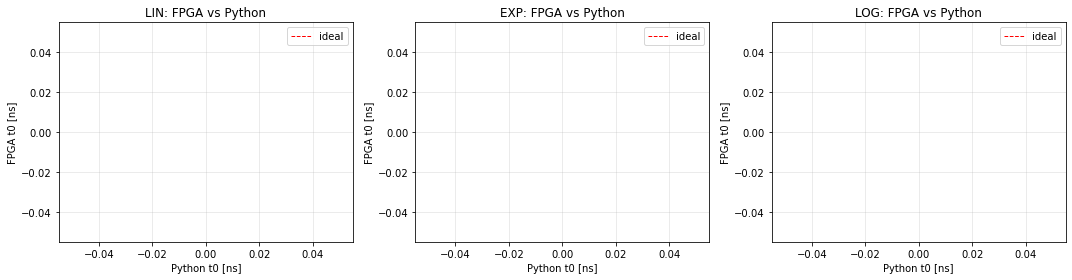

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mode in zip(axes, MODE_NAMES):
    sub = res[res['mode'] == mode].dropna(subset=['fpga_t0','python_t0'])
    ax.scatter(sub['python_t0'], sub['fpga_t0'], s=20, alpha=0.8)
    lims = [min(sub['python_t0'].min(), sub['fpga_t0'].min()),
            max(sub['python_t0'].max(), sub['fpga_t0'].max())]
    ax.plot(lims, lims, 'r--', lw=1, label='ideal')
    ax.set_xlabel('Python t0 [ns]')
    ax.set_ylabel('FPGA t0 [ns]')
    ax.set_title(f'{mode}: FPGA vs Python')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fpga_vs_python.png', dpi=100)
plt.show()

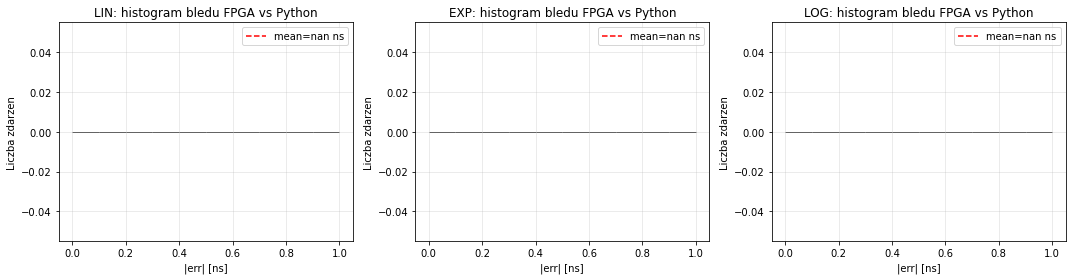

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mode in zip(axes, MODE_NAMES):
    sub = res[res['mode'] == mode]['err_vs_python'].dropna()
    ax.hist(sub, bins=10, edgecolor='black', alpha=0.7)
    ax.axvline(sub.mean(), color='red', linestyle='--', label=f'mean={sub.mean():.3f} ns')
    ax.set_xlabel('|err| [ns]')
    ax.set_ylabel('Liczba zdarzen')
    ax.set_title(f'{mode}: histogram bledu FPGA vs Python')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_histogram.png', dpi=100)
plt.show()

## 9. Pomiar wydajności: ARM vs FPGA

In [30]:
N_BENCH = 100
row = df.iloc[0]
t1,a1,t2,a2,t3,a3 = row['t1'],row['A1'],row['t2'],row['A2'],row['t3'],row['A3']

# ARM
t0_arm = time.time()
for _ in range(N_BENCH):
    python_linear(t1, a1, t2, a2, THRESHOLD)
    python_exponential(t1, a1, t2, a2, THRESHOLD)
    python_logarithmic(t1, a1, t2, a2, t3, a3, THRESHOLD)
arm_time = (time.time() - t0_arm) / N_BENCH * 1e6

# FPGA (wszystkie 3 metody)
t0_fpga = time.time()
for _ in range(N_BENCH):
    for m in MODES:
        fpga_compute(t1, a1, t2, a2, t3, a3, THRESHOLD, m)
fpga_time = (time.time() - t0_fpga) / N_BENCH * 1e6

print(f'ARM  (3 metody): {arm_time:.1f} us / zdarzenie')
print(f'FPGA (3 metody): {fpga_time:.1f} us / zdarzenie  (z AXI overhead)')
print(f'Przyspieszenie:  {arm_time/fpga_time:.2f}x')

ARM  (3 metody): 136.2 us / zdarzenie
FPGA (3 metody): 275938.0 us / zdarzenie  (z AXI overhead)
Przyspieszenie:  0.00x


## 10. Zapis wyników do CSV

In [31]:
res.to_csv('wyniki_fpga.csv', index=False, float_format='%.6f')
print('Zapisano wyniki_fpga.csv')
res.head(6)

Zapisano wyniki_fpga.csv


,event_id,mode,fpga_t0,python_t0,true_t0,err_vs_python,err_vs_true,overflow,time_s
0,0,LIN,None,12.9387,13.0911,None,None,None,0.0952
1,0,EXP,None,13.2697,13.0911,None,None,None,0.0938
2,0,LOG,None,13.2697,13.0911,None,None,None,0.0937
3,1,LIN,None,14.6870,14.6559,None,None,None,0.0919
4,1,EXP,None,14.6210,14.6559,None,None,None,0.0922
5,1,LOG,None,14.6210,14.6559,None,None,None,0.0938
